# 03 Exploratory Data Analysis



Cell 1 — Setup & Load Data


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

In [10]:
DATA_PATH = PROJECT_ROOT / 'data/processed/Beijing PM25 Data Cleaned.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,datetime,year,month,day,hour,pm2_5,pm2_5_cleaned,dew_point,temperature,pressure,wind_direction,wind_speed,hours_snow,hours_rain
0,2010-01-01 00:00:00,2010,1,1,0,NaN,129.0,-21,-11.0,1021.0,NW,1.79,0,0
1,2010-01-01 01:00:00,2010,1,1,1,NaN,129.0,-21,-12.0,1020.0,NW,4.92,0,0
2,2010-01-01 02:00:00,2010,1,1,2,NaN,129.0,-21,-11.0,1019.0,NW,6.71,0,0
3,2010-01-01 03:00:00,2010,1,1,3,NaN,129.0,-21,-14.0,1019.0,NW,9.84,0,0
4,2010-01-01 04:00:00,2010,1,1,4,NaN,129.0,-20,-12.0,1018.0,NW,12.97,0,0


In [11]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,43824,NaN,NaN,NaN,2012-07-01 23:30:00,2010-01-01 00:00:00,2011-04-02 11:45:00,2012-07-01 23:30:00,2013-10-01 11:15:00,2014-12-31 23:00:00,NaN
year,43824.0,NaN,NaN,NaN,2012.0,2010.0,2011.0,2012.0,2013.0,2014.0,1.413842
month,43824.0,NaN,NaN,NaN,6.523549,1.0,4.0,7.0,10.0,12.0,3.448572
day,43824.0,NaN,NaN,NaN,15.72782,1.0,8.0,16.0,23.0,31.0,8.799425
hour,43824.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922266
pm2_5,41757.0,NaN,NaN,NaN,98.613215,0.0,29.0,72.0,137.0,994.0,92.050387
pm2_5_cleaned,43824.0,NaN,NaN,NaN,97.801114,0.0,29.0,72.0,136.0,994.0,91.376429
dew_point,43824.0,NaN,NaN,NaN,1.817246,-40.0,-10.0,2.0,15.0,28.0,14.43344
temperature,43824.0,NaN,NaN,NaN,12.448521,-19.0,2.0,14.0,23.0,42.0,12.198613
pressure,43824.0,NaN,NaN,NaN,1016.447654,991.0,1008.0,1016.0,1025.0,1046.0,10.268698


# Plot 1 — PM2.5 Distribution (Histogram)



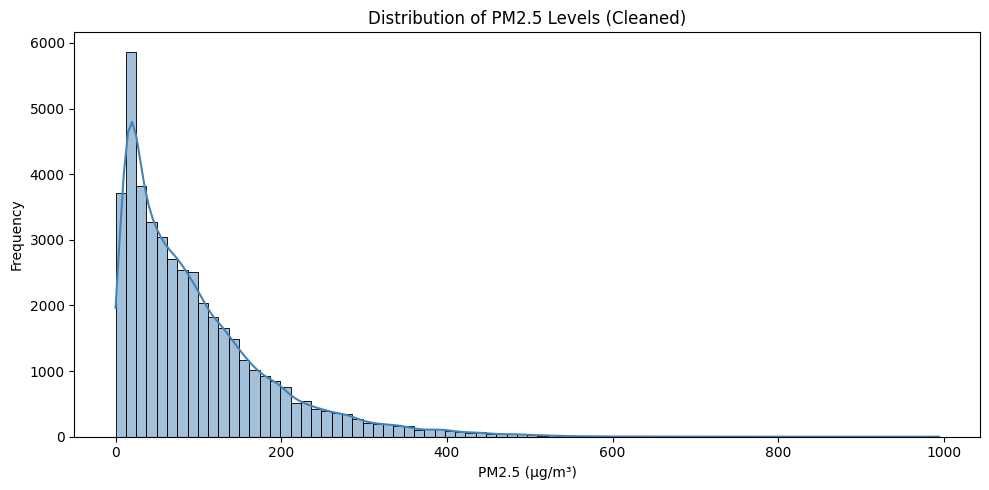

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['pm2_5_cleaned'].dropna(), bins=80, kde=True, color='steelblue')
plt.title('Distribution of PM2.5 Levels (Cleaned)')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot1_pm25_distribution.png', dpi=150)
plt.show()

# Plot 2 — Monthly Average PM2.5 (Bar Chart)

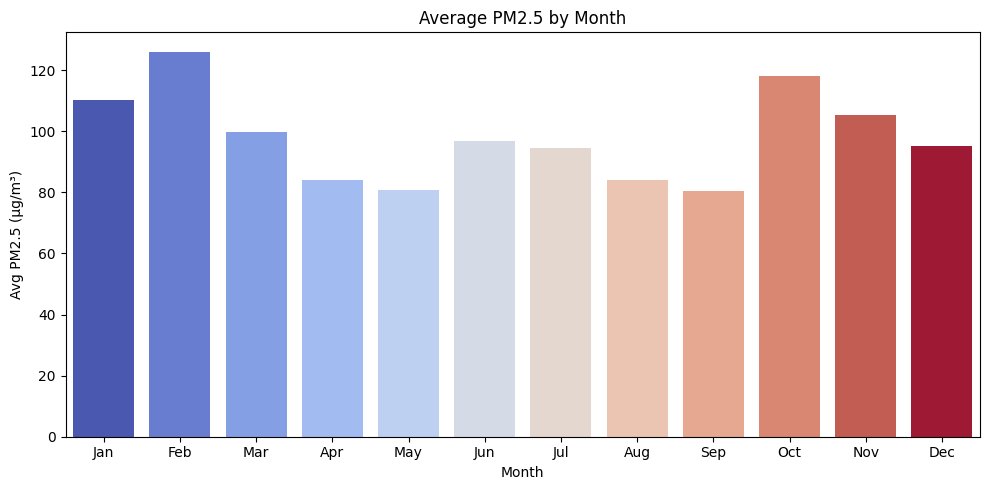

In [25]:
monthly_avg = df.groupby('month')['pm2_5_cleaned'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, hue=monthly_avg.index, palette='coolwarm', legend=False)
plt.xticks(ticks=range(12), labels=month_names)
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot2_monthly_avg_pm25.png', dpi=150)
plt.show()

# Plot 3 — Hourly Average PM2.5 (Line Plot)

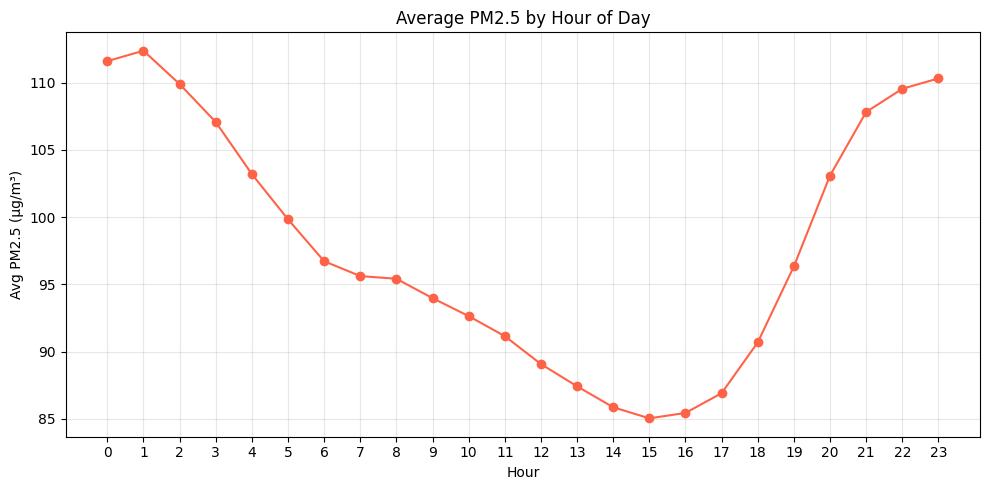

In [15]:
hourly_avg = df.groupby('hour')['pm2_5_cleaned'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='tomato')
plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_hourly_avg_pm25.png', dpi=150)
plt.show()

# Plot 4 — Yearly Trend of PM2.5 (Box Plot)

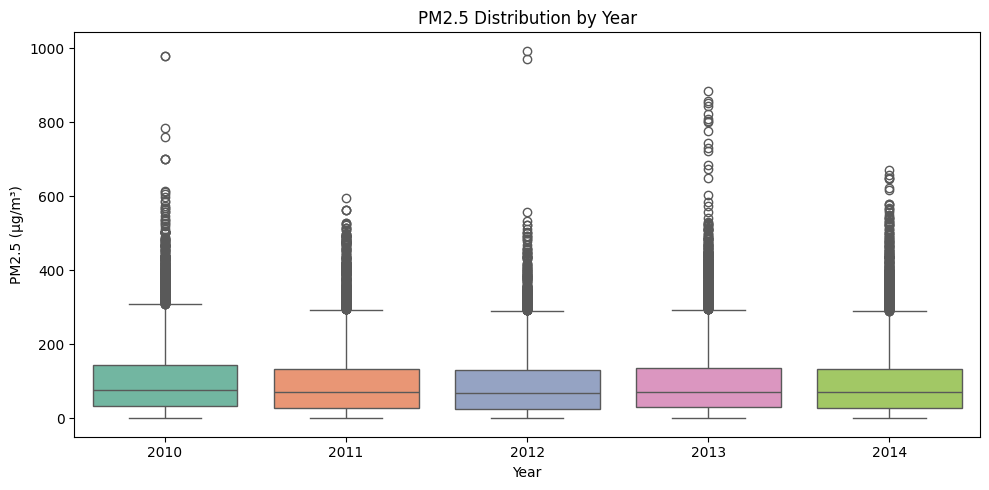

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='year', y='pm2_5_cleaned', hue='year', palette='Set2', legend=False)
plt.title('PM2.5 Distribution by Year')
plt.xlabel('Year')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot4_yearly_boxplot.png', dpi=150)
plt.show()

# Plot 5 — Monthly PM2.5 Box Plot (Seasonal Patterns)

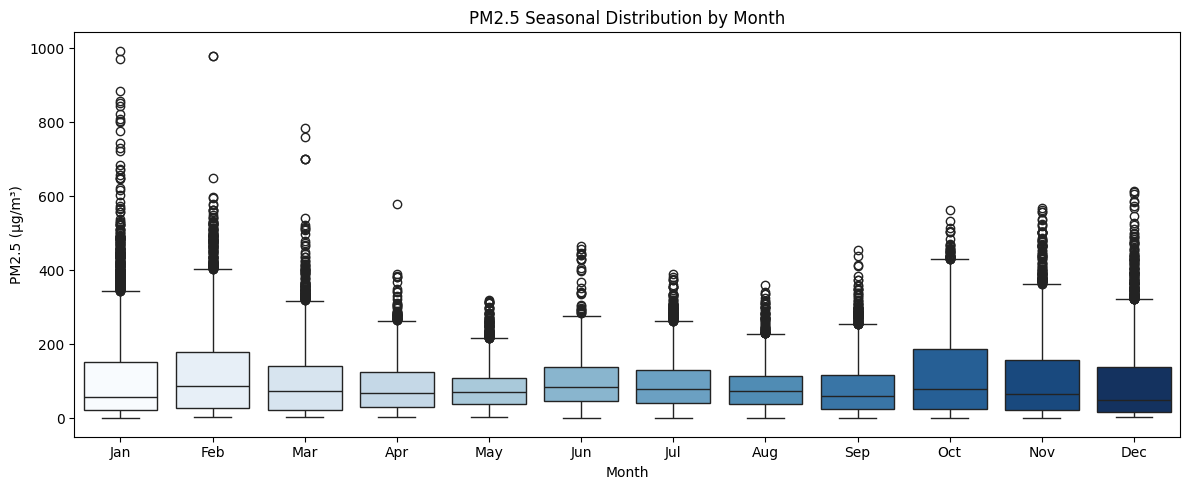

In [27]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='month', y='pm2_5_cleaned', hue='month', palette='Blues', legend=False)
plt.xticks(ticks=range(12), labels=month_names)
plt.title('PM2.5 Seasonal Distribution by Month')
plt.xlabel('Month')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot5_monthly_boxplot.png', dpi=150)
plt.show()

# Plot 6 — Correlation Heatmap

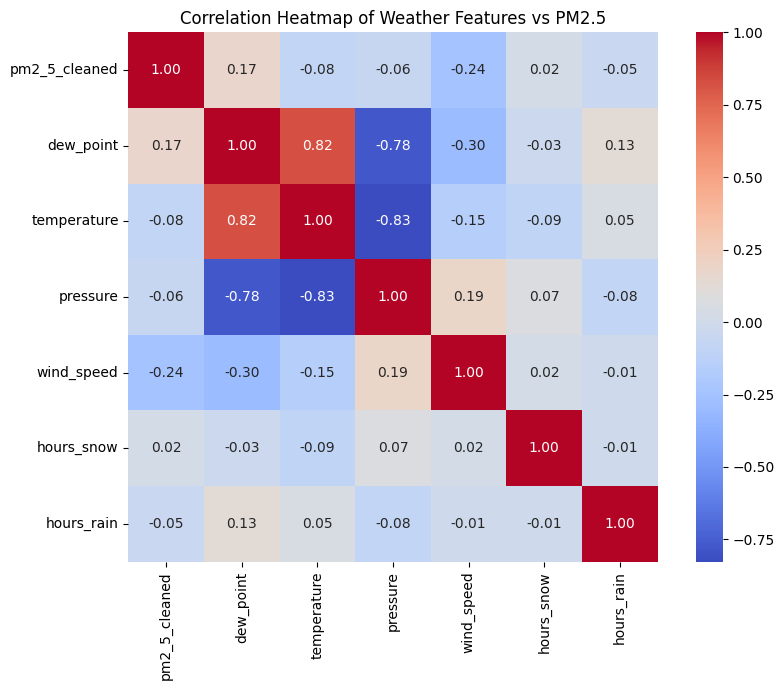

In [18]:
num_cols = ['pm2_5_cleaned', 'dew_point', 'temperature', 'pressure', 'wind_speed', 'hours_snow', 'hours_rain']

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Weather Features vs PM2.5')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150)
plt.show()

# Plot 7 — Wind Direction vs PM2.5 (Bar Chart)

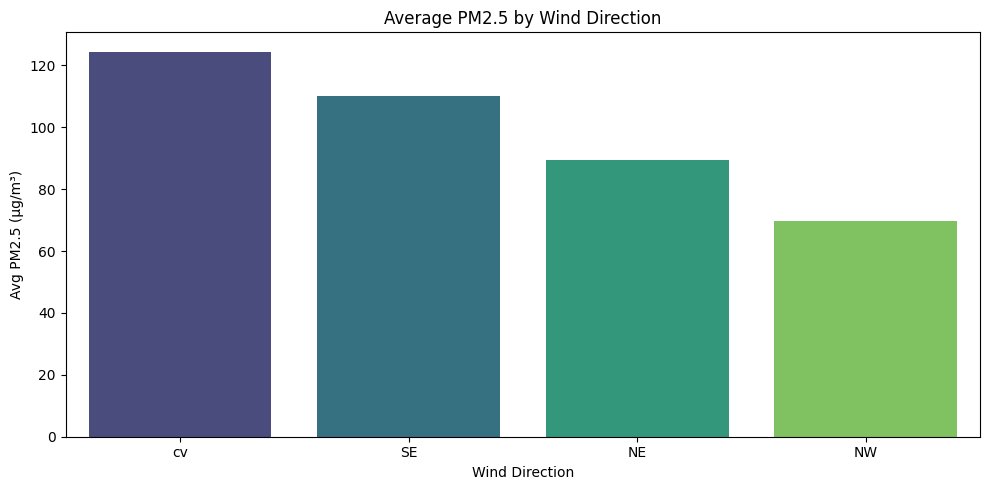

In [26]:
wind_pm = df.groupby('wind_direction')['pm2_5_cleaned'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=wind_pm.index, y=wind_pm.values, hue=wind_pm.index, palette='viridis', legend=False)
plt.title('Average PM2.5 by Wind Direction')
plt.xlabel('Wind Direction')
plt.ylabel('Avg PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('plot7_wind_direction_pm25.png', dpi=150)
plt.show()